In [2]:
import zipfile

with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("Training.csv")
df.head()

,very_dry_skin,sores_that_heal_slowly,more_infections_than_usual,Unnamed: 3,Unnamed: 4,nausea,stomach_pains,Unnamed: 7,urinate_a_lot,feel_very_thirsty,...,high_temperature,chest_pain,aching_body,feeling_very_tired,wheezing_noises_when_you_breathe,Unnamed: 36,Unnamed: 37,Unnamed: 38,feeling_confused,disease
0,1,1,1,NaN,NaN,1,1,NaN,0,0,...,0,0,0,0,0,NaN,NaN,NaN,0,diabetes
1,1,1,1,NaN,NaN,1,1,NaN,0,0,...,0,0,0,0,0,NaN,NaN,NaN,0,diabetes
2,1,1,1,NaN,NaN,1,1,NaN,1,0,...,0,0,0,0,0,NaN,NaN,NaN,0,diabetes
3,1,1,1,NaN,NaN,1,1,NaN,0,0,...,0,0,0,0,0,NaN,NaN,NaN,0,diabetes
4,1,1,1,NaN,NaN,1,1,NaN,1,1,...,0,0,0,0,0,NaN,NaN,NaN,0,diabetes


In [7]:
df.shape
df['disease'].value_counts().head()

,count
disease,
pneumonia,65
diabetes,64
dengue,61
hepatitas,32


In [6]:
df.columns.tolist()

['very_dry_skin',
 'sores_that_heal_slowly',
 'more_infections_than_usual',
 'Unnamed: 3',
 'Unnamed: 4',
 'nausea',
 'stomach_pains',
 'Unnamed: 7',
 'urinate_a_lot',
 'feel_very_thirsty',
 'lose_weight_without_trying',
 'blurry_vision',
 'itching_hands_or_feet',
 'feel_very_hungry',
 'fever',
 'fatigue',
 'loss_of_appetite',
 'vomiting',
 'abdominal_pain',
 'dark_urine',
 'light_colored_stools',
 'joint_pain',
 'jaundice',
 'rash',
 'bone_pain',
 'joint_pain.1',
 'muscle_pain',
 'cramp',
 'eye_pain',
 'cough_with_yellow_or_green mucus ',
 'shortness_of_breath',
 'high_temperature',
 'chest_pain',
 'aching_body',
 'feeling_very_tired',
 'wheezing_noises_when_you_breathe ',
 'Unnamed: 36',
 'Unnamed: 37',
 'Unnamed: 38',
 'feeling_confused',
 'disease']

In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv("Training.csv")

# Drop unnamed columns
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

df.shape

(222, 35)

In [9]:
df.head()

,very_dry_skin,sores_that_heal_slowly,more_infections_than_usual,nausea,stomach_pains,urinate_a_lot,feel_very_thirsty,lose_weight_without_trying,blurry_vision,itching_hands_or_feet,...,eye_pain,cough_with_yellow_or_green mucus,shortness_of_breath,high_temperature,chest_pain,aching_body,feeling_very_tired,wheezing_noises_when_you_breathe,feeling_confused,disease
0,1,1,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,diabetes
1,1,1,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,diabetes
2,1,1,1,1,1,1,0,0,1,1,...,0,0,0,0,0,0,0,0,0,diabetes
3,1,1,1,1,1,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,diabetes
4,1,1,1,1,1,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,diabetes


In [10]:
df['disease'].value_counts().head()

,count
disease,
pneumonia,65
diabetes,64
dengue,61
hepatitas,32


In [11]:
df.isnull().sum().sum()

np.int64(0)

In [12]:
X = df.drop('disease', axis=1)
y = df['disease']

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

X_train.shape, X_test.shape

((177, 34), (45, 34))

In [15]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score

nb = BernoulliNB()
nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)
nb_acc = accuracy_score(y_test, nb_pred)
nb_acc

1.0

In [16]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=None
)

dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)
dt_acc

0.9777777777777777

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
rf_acc

1.0

In [18]:
print("Naive Bayes Accuracy:", nb_acc)
print("Decision Tree Accuracy:", dt_acc)
print("Random Forest Accuracy:", rf_acc)

Naive Bayes Accuracy: 1.0
Decision Tree Accuracy: 0.9777777777777777
Random Forest Accuracy: 1.0


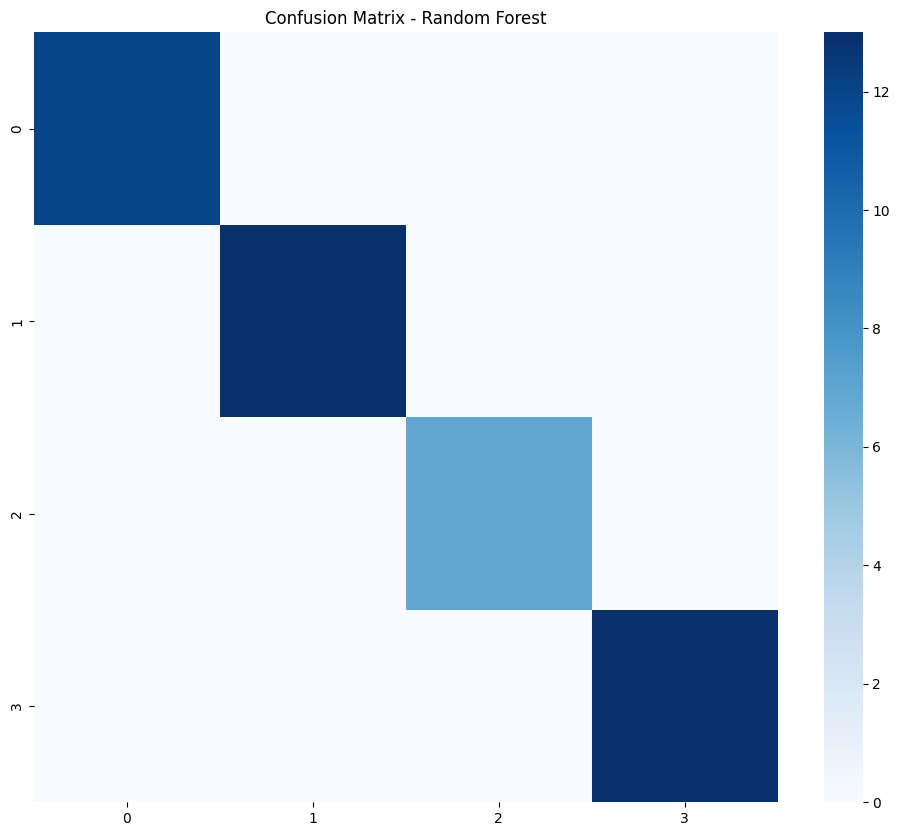

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         7
           3       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

print(classification_report(y_test, rf_pred))

In [23]:
def predict_disease(symptom_list):
    input_data = pd.DataFrame(
        np.zeros((1, len(X.columns))),
        columns=X.columns
    )

    for symptom in symptom_list:
        if symptom in input_data.columns:
            input_data.at[0, symptom] = 1

    prediction = rf.predict(input_data)[0]
    return le.inverse_transform([prediction])[0]

In [24]:
predict_disease(['fever', 'headache', 'fatigue'])

'hepatitas'

In [22]:
import joblib

joblib.dump(rf, "disease_model.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [25]:
print("Naive Bayes Accuracy:", nb_acc)
print("Decision Tree Accuracy:", dt_acc)
print("Random Forest Accuracy:", rf_acc)

Naive Bayes Accuracy: 1.0
Decision Tree Accuracy: 0.9777777777777777
Random Forest Accuracy: 1.0
